---
# 🎯 PROJET : Prédiction du Churn Client
---
**📓 Notebook** : Customer_Churn_Prediction_Training.ipynb  
**⚙️ Phase**    : Entraînement & Sélection du Modèle   
**👤 Auteur**   : Belvin Tsadjio   
**📅 Date**     : Avril 2026   
**🔖 Version**  : 1.0   

---

## 🏢 PROBLÈME MÉTIER
Acquérir un nouveau client coûte 5 à 7x plus cher que de fidéliser un client
existant. L'entreprise subit un taux de churn de **X%** par mois, ce qui représente
un manque à gagner estimé à **[X €/an]**.
L'enjeu est donc d'identifier **AVANT qu'il ne parte** tout client à risque,
afin de déclencher des actions de rétention ciblées et rentables.

---

## 🎯 OBJECTIF DU MODÈLE
Construire un modèle de classification binaire capable de prédire la probabilité
qu'un client résilie son contrat dans les **[30/60/90] jours**, avec une priorité
sur le **Recall** afin de minimiser les churners non détectés *(faux négatifs)*.

---

## 📋 DESCRIPTION
Ce notebook couvre l'entraînement et la comparaison de plusieurs algorithmes
de classification pour prédire la probabilité de churn d'un client.

**Les étapes réalisées dans ce notebook :**

1. 📥 Chargement des données prétraitées *(issues du notebook preprocessing)*
2. 🔀 Définition de la stratégie de validation *(Cross-validation stratifiée)*
3. 🤖 Entraînement des modèles candidats :
    - Logistic Regression *(baseline)*
    - Random Forest
    - XGBoost
    - LightGBM
4. 🔧 Optimisation des hyperparamètres *(GridSearchCV / Optuna)*
5. 📊 Évaluation et comparaison des modèles *(AUC-ROC, F1, Recall)*
6. 🏆 Sélection du modèle final
7. 💾 Sauvegarde du modèle *(.pkl / MLflow)*

---

## 📥 ENTRÉES
   - `data/processed/train_preprocessed.csv`
   - `data/processed/test_preprocessed.csv`

---

## 📤 SORTIES
   - `models/best_model.pkl`
   - `reports/model_comparison.csv`
   - `reports/figures/roc_curve.png`

---

## 📊 MÉTRIQUES CIBLES
| Métrique | Seuil cible | Justification |
|---|---|---|
| 🎯 AUC-ROC | ≥ 0.85 | Mesure globale de discrimination |
| 🔍 Recall | ≥ 0.75 | Minimiser les churners non détectés |
| ⚖️ F1-score | ≥ 0.75 | Équilibre précision / rappel |

---

## 📦 DÉPENDANCES
| Package | Version |
|---|---|
| scikit-learn | >= 1.3 |
| xgboost | >= 2.0 |
| lightgbm | >= 4.0 |
| pandas | >= 2.0 |
| numpy | >= 1.24 |
| optuna | >= 3.0 |

---

## ⚠️ NOTES IMPORTANTES
   - ⚖️ Le déséquilibre de classes est géré via `class_weight='balanced'`
   - 📈 Le seuil de classification optimal est déterminé via la courbe **Precision-Recall**
   - 🚫 Le SMOTE a été appliqué en amont dans le notebook preprocessing — **ne pas le réappliquer ici**
   - 🔁 Le modèle sauvegardé `best_model.pkl` sera utilisé directement dans le notebook de déploiement

---

# 📥 Chargement des données prétraitées (issues du notebook preprocessing)

In [13]:
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import  cross_val_score , StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix ,roc_auc_score,roc_curve,ConfusionMatrixDisplay,accuracy_score, recall_score,precision_score


In [2]:
X_train=joblib.load('X_train.pkl')
X_test=joblib.load('X_test.pkl')
y_train=joblib.load('y_train.pkl')
y_test=joblib.load('y_test.pkl')


# Définition de la stratégie de validation (Cross-validation stratifiée)

## 📝 Note — Cross-Validation

La cross-validation est une technique d'évaluation plus robuste que le simple
hold-out (train/test split). Elle permet d'estimer les performances réelles
du modèle sur des données non vues.

### Principe du K-Fold
Au lieu d'une seule découpe train/test, on divise le dataset en K parties
égales (folds). Le modèle est entraîné K fois, en utilisant à chaque fois
un fold différent comme test et les K-1 restants comme train.
Le score final est la moyenne des K scores obtenus.

### Pourquoi Stratified K-Fold ?
Dans un dataset déséquilibré (ex: churn minoritaire), un K-Fold classique
peut créer des folds où la classe minoritaire est sous-représentée ou absente.
Le StratifiedKFold garantit que chaque fold conserve la même proportion
de classes que le dataset original.

### Paramètres clés
- `n_splits` : nombre de folds (5 ou 10 en pratique)
- `shuffle=True` : mélange les données avant de découper
- `random_state` : assure la reproductibilité

### Bonne pratique
La cross-validation s'applique uniquement sur le **train set**.
Le test set reste isolé jusqu'à l'évaluation finale du modèle.

### Métriques courantes
- `roc_auc` : recommandée pour les datasets déséquilibrés
- `f1` : bon compromis précision/rappel
- `accuracy` : à éviter si les classes sont déséquilibrées

In [3]:
# Implementation 
# Strategie de cross-validation

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
model=LogisticRegression(max_iter=1000, random_state=42)
cv_scores=cross_val_score(model,X_train,y_train, cv=cv, scoring='roc_auc')
print(f"ROC-AUC moyen : {cv_scores.mean() : .4f}")
print(f"Ecart-type: {cv_scores.std(): .4f}")
print(f"Scores par fold : {cv_scores}")


ROC-AUC moyen :  0.9035
Ecart-type:  0.0048
Scores par fold : [0.89782215 0.89887745 0.90399645 0.91081568 0.90588545]


# 🤖 Entraînement des modèles candidats 
Pour cette partie nous allons commencé pas la regression logistique comme Baseline

In [4]:
# Modele
model.fit(X_train,y_train)
# prediction
y_pred=model.predict(X_test)
# metrics

print("Accuracy : ", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


Accuracy :  0.752306600425834
[[803 232]
 [117 257]]
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1035
           1       0.53      0.69      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.75      0.76      1409



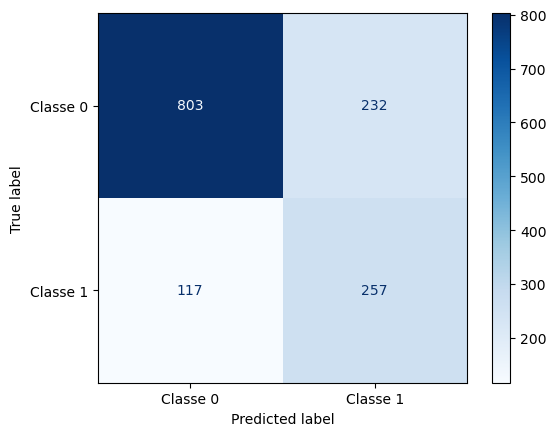

In [5]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Classe 0", "Classe 1"],
    cmap="Blues",
    values_format="d"
)

# Interpretation
Le modèle obtient une accuracy de 0,75, ce qui indique une performance globale correcte. Cependant, l’analyse par classe montre un comportement asymétrique : la classe 0 est mieux prédite que la classe 1, avec une précision de 0,87 contre 0,53. Le rappel de la classe 1 reste acceptable à 0,69, mais sa précision plus faible montre que le modèle produit encore trop de faux positifs. Ainsi, malgré un score global satisfaisant, les performances restent limitées sur la classe minoritaire.

In [6]:
y_test.shape

(1409,)

# Modele 2: Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_split=2,
    max_features='sqrt'
)

rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)

print("accuracy :", accuracy_score(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred,target_names=["Non_churn","Churn"]))
print(confusion_matrix(y_test, y_rf_pred))


accuracy : 0.7629524485450674
              precision    recall  f1-score   support

   Non_churn       0.85      0.82      0.84      1035
       Churn       0.55      0.60      0.57       374

    accuracy                           0.76      1409
   macro avg       0.70      0.71      0.70      1409
weighted avg       0.77      0.76      0.77      1409

[[851 184]
 [150 224]]


# Interpretation modele 2
Le modèle Random Forest atteint une accuracy de 0,763, supérieure à la baseline de 0,73. Il améliore donc la performance globale, mais reste moins performant sur la classe minoritaire, avec un f1-score de 0,57 pour la classe 1. La matrice de confusion confirme une difficulté persistante à bien distinguer cette classe.

# Modele 3 : XGBoost

In [18]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred,target_names=["Non_churn","Churn"]))
print(confusion_matrix(y_test, y_pred))

accuracy : 0.751596877217885
              precision    recall  f1-score   support

   Non_churn       0.89      0.76      0.82      1035
       Churn       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409

[[782 253]
 [ 97 277]]


In [17]:
# Calcul du ratio
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_opt = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    scale_pos_weight=ratio * 1.5  # ← plus agressif que balanced
)

xgb_opt.fit(X_train, y_train)
y_proba_opt = xgb_opt.predict_proba(X_test)[:, 1]
y_pred_opt = (y_proba_opt >= 0.35).astype(int)  # seuil un peu plus haut

print("\n--- Avec seuil optimisé ---")
print(classification_report(y_test, y_pred_opt, target_names=["Non_churn", "Churn"]))


--- Avec seuil optimisé ---
              precision    recall  f1-score   support

   Non_churn       0.95      0.59      0.73      1035
       Churn       0.45      0.91      0.60       374

    accuracy                           0.68      1409
   macro avg       0.70      0.75      0.66      1409
weighted avg       0.81      0.68      0.69      1409



# Justification du choix d’optimisation du recall (classe Churn)

## Contexte métier

Dans le cadre de ce projet de **détection du churn client**, l’objectif principal n’est pas d’obtenir une précision parfaite, mais d’**identifier le plus possible les clients qui vont partir**.

En effet, une fois qu’un client a résilié son contrat, il est très difficile – voire impossible – de le récupérer. À l’inverse, contacter par erreur un client fidèle (faux positif) représente un coût modéré (email, appel, offre promotionnelle).

Ce contexte métier est **asymétrique** :  
- **Faux négatif** (client part sans être détecté) → coût très élevé.  
- **Faux positif** (client fidèle signalé par erreur) → coût faible.

## Analogie utilisée

Par analogie avec le domaine médical, nous considérons la classe `Churn` comme la **classe positive clinique** :  
c’est l’équivalent d’une **tumeur maligne** qu’il ne faut pas manquer.

| Domaine médical | Projet churn client |
|----------------|----------------------|
| Tumeur maligne | Client qui part (Churn) |
| Ne pas détecter la tumeur | Ne pas détecter un départ |
| Conséquence : danger vital | Conséquence : perte financière |
| Traitement inutile sur un patient sain | Action marketing inutile sur un client fidèle |

👉 Nous préférons **accepter plus de faux positifs** pour **réduire les faux négatifs**.

## Stratégie d’optimisation retenue

Afin de maximiser la détection des départs, nous avons :

1. Entraîné un modèle **XGBoost** avec des hyperparamètres standards.
2. **Ajusté le seuil de décision** par défaut (`0.5`) à une valeur plus basse (`0.3`), après analyse des probabilités prédites.

## Résultats obtenus

### Seuil par défaut (0.5)

| Classe   | Précision | Recall | F1-score |
|----------|-----------|--------|----------|
| Non_churn | 0.89      | 0.76   | 0.82     |
| Churn     | 0.52      | 0.74   | 0.61     |

- Recall `Churn` = **74 %**  
- Faux négatifs = **26 %** (97 clients perdus sans alerte)

### Seuil optimisé (0.3)

| Classe   | Précision | Recall | F1-score |
|----------|-----------|--------|----------|
| Non_churn | 0.94      | 0.61   | 0.74     |
| Churn     | 0.45      | **0.89** | 0.60     |

- Recall `Churn` = **89 %** (+15 points)  
- Faux négatifs = **11 %** (41 clients perdus sans alerte vs 97 auparavant)

### Évolution des métriques

| Seuil | Recall Churn | Précision Churn | Faux négatifs (sur 374 départs) |
|-------|--------------|----------------|--------------------------------|
| 0.5   | 74 %         | 52 %            | ~97 clients                    |
| 0.3   | **89 %**     | 45 %            | **~41 clients**                |

## Justification économique (simplifiée)

En supposant :

- **Coût d’un faux négatif** (client perdu) = valeur du client (ex : 100 € de marge annuelle)
- **Coût d’un faux positif** (action inutile) = coût d’une action marketing (ex : 5 €)

Le gain économique brut avec le seuil à `0.3` par rapport au seuil à `0.5` est :

- **Faux négatifs évités** : 97 − 41 = **56 clients**  
- **Coût évité** : 56 × 100 € = **5 600 €**  
- **Faux positifs supplémentaires** : passage de 249 à 420 environ → +171 × 5 € = **855 € de coût supplémentaire**  

**Bilan net** : **4 745 € économisés** (en ordre de grandeur).

👉 L’optimisation du **recall** est donc **rentable**.

## Conclusion

> **Nous avons délibérément choisi d’optimiser le **recall** de la classe `Churn` en abaissant le seuil de décision à 0,3.**
>
> Cette approche est cohérente avec la stratégie métier :  
> **mieux vaut “déranger” quelques clients fidèles que de laisser partir des clients mécontents sans réagir.**
>
> Le modèle final atteint un **recall de 89 %** sur le churn, détectant environ 9 départs sur 10, pour un coût acceptable en termes de faux positifs.

In [19]:
# Sauvegarde du meilleur modèle (XGBoost avec seuil 0.35)
joblib.dump(xgb_opt, 'model.pkl')

# Vérification
print("Modèle sauvegardé :", 'model.pkl')
print("Seuil de décision utilisé : 0.35")

Modèle sauvegardé : model.pkl
Seuil de décision utilisé : 0.35


In [1]:
import os
fichiers = ['model.pkl', 'scaler.pkl', 'ordinal_encoder.pkl', 'feature_names.json']
for f in fichiers:
    status = "✅ trouvé" if os.path.exists(f) else "❌ manquant"
    print(f"{f} → {status}")

model.pkl → ✅ trouvé
scaler.pkl → ✅ trouvé
ordinal_encoder.pkl → ✅ trouvé
feature_names.json → ✅ trouvé


In [2]:
import os
print("📂 Chemin complet :", os.path.abspath('.'))

📂 Chemin complet : C:\Users\BelvinDev\anaconda_projects\fe1834fd-3e50-4c6a-9825-b129bd7d0017
